# AFC Lab — Fatigue Detection v9 (PhysioNet-only — multi-dataset ОТКЛЮЧЕН)

> ⚠️ **Исследование показало:** комбинирование 4TU/Zenodo/WSD с PhysioNet СИСТЕМАТИЧЕСКИ УХУДШАЕТ метрику на PhysioNet test (−5–9pp от v8.1 baseline 0.826). Подробности — `docs/v8_experiments_summary.md` §6. Поэтому в текущей версии выставлен флаг `USE_ONLY_PHYSIONET = True` — используем только PhysioNet (23K окон, 31 субъект).\n\n**Стратегия (обновленная):** работаем только на PhysioNet, но с улучшенной архитектурой (SE+FiLM-by-domain, R-Drop) и более сильными регуляризаторами, чем v8.1.

## Обоснование

Эксперименты v7–v8 показали потолок F1≈0.82 на одном PhysioNet. Диагноз: **информационный потолок**, а не архитектурный. Нам нужно **больше данных** разной природы.

| Датасет | Окон | Subjects | Has Physio | Метки |
|---------|------|----------|------------|-------|
| PhysioNet (Empatica E4, ex.) | 23 034 | 31 | ✅ BVP+EDA+TEMP+HR | 43% fatigue |
| WSD4FedSRM (wrist) | 1 123 | 34 | ❌ IMU-only | 71% fatigue |
| Composite (4TU+Zenodo) | 24 868 | 27 | ❌ IMU-only | 50% fatigue |
| **Всего** | **~49 025** | **~92** | смешанно | |

## Ключевые отличия от v8

1. **Multi-dataset training** — все 3 датасета в одном loader, упражнения разные
2. **Domain embedding + FiLM** — модель явно знает, откуда пришло окно (4 домена)
3. **`has_physio` маска** — physio-ветка обнуляется, когда сигнала нет (4TU/Zenodo/WSD)
4. **Убрана stress profile** — ablation в v8 показал, что она вредит
5. **Domain-weighted loss** — PhysioNet-окна с весом ×1.5 (главная задача)
6. **Test = только PhysioNet held-out subjects** — apples-to-apples с v8.1 (0.826)

## Цель: F1-macro > 0.826 на PhysioNet test


In [1]:
import neurokit2 as nk

import os, sys, math, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import (f1_score, roc_auc_score, average_precision_score,
                              balanced_accuracy_score, classification_report,
                              confusion_matrix, precision_recall_curve)
from imblearn.over_sampling import SMOTE
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

SEED = 44682
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}, Torch: {torch.__version__}")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR     = PROJECT_ROOT / 'data' / 'processed'
RESULTS_DIR  = (PROJECT_ROOT / 'results_v9_multidataset').resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Data:    {DATA_DIR}")
print(f"Results: {RESULTS_DIR}")

CONFIG = {
    # Data
    'imu_channels': 6,
    'physio_channels': 4,
    'window_len': 100,
    'n_domains': 4,
    'domain_emb': 6,
    'use_domain_in_classifier': False,
    # Architecture
    'encoder_channels': 24,
    'physio_encoder_channels': 24,
    'kernel_sizes': [7, 5, 3, 3],
    'attention_heads': 4,
    'use_se': True,
    'physio_use_pool': True,
    'encoder_dropout': 0.40,
    'classifier_dropout': 0.50,
    'drop_path_rate': 0.10,
    # Training
    'batch_size': 32,
    'epochs': 60,
    'lr': 7e-5,
    'warmup_epochs': 6,
    'weight_decay': 4e-2,
    'patience': 8,
    'min_delta': 1e-4,
    'focal_gamma': 2.2,
    'label_smoothing': 0.08,
    'mixup_alpha': 0.3,
    'rdrop_alpha': 0.10,
    # SWA — FIX: старт раньше чтобы усреднять веса на подъёме, а не после пика
    'swa_start_frac': 0.20,        # FIX: 0.40 → 0.20 (старт ~epoch 12, до пика)
    'swa_lr': 4e-5,                # FIX: константный LR во время SWA (≈ пиковый)
    # Fine-tune phase: freeze encoder → учим только classifier+FiLM+dom_emb
    # Цель: после SWA уточнить decision boundary без переобучения representations
    'finetune_epochs': 10,         # FIX: 0 → 10
    'finetune_lr': 2e-5,           # FIX: 5e-5 → 2e-5 (очень осторожно)
    'finetune_patience': 5,        # early stopping отдельно для fine-tune фазы
    # Domain weighting
    'physionet_weight': 1.0,
    'other_weight': 1.0,
    'cap_per_other_domain': None,
    # Eval
    'tta_n': 5,
}

USE_ONLY_PHYSIONET = True
print("\nCONFIG:")
for k, v in CONFIG.items(): print(f"  {k}: {v}")


Device: cuda, Torch: 2.10.0+cu130
Data:    d:\Github\afc_lab\data\processed
Results: D:\Github\afc_lab\results_v9_multidataset

CONFIG:
  imu_channels: 6
  physio_channels: 4
  window_len: 100
  n_domains: 4
  domain_emb: 6
  use_domain_in_classifier: False
  encoder_channels: 24
  physio_encoder_channels: 24
  kernel_sizes: [7, 5, 3, 3]
  attention_heads: 4
  use_se: True
  physio_use_pool: True
  encoder_dropout: 0.4
  classifier_dropout: 0.5
  drop_path_rate: 0.1
  batch_size: 32
  epochs: 60
  lr: 7e-05
  warmup_epochs: 6
  weight_decay: 0.04
  patience: 8
  min_delta: 0.0001
  focal_gamma: 2.2
  label_smoothing: 0.08
  mixup_alpha: 0.3
  rdrop_alpha: 0.1
  swa_start_frac: 0.2
  swa_lr: 4e-05
  finetune_epochs: 10
  finetune_lr: 2e-05
  finetune_patience: 5
  physionet_weight: 1.0
  other_weight: 1.0
  cap_per_other_domain: None
  tta_n: 5


## 1. Загрузка и объединение датасетов

Объединяем 3 источника в единые массивы. Для датасетов без physio (4TU/Zenodo/WSD) `X_physio = zeros`, `has_physio = False` — модель сама обнулит вклад этой ветки через маску.

Domain mapping:
- 0: `physionet`
- 1: `wsd4fedsrm`
- 2: `4tu`
- 3: `zenodo`


In [2]:
# ── Project root & paths ──
def find_project_root(marker='config.yaml', start=None, max_levels=5):
    current = Path(start or os.getcwd()).resolve()
    for _ in range(max_levels):
        if (current / marker).exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise FileNotFoundError(f"Marker '{marker}' not found from {os.getcwd()}")

PROJECT_ROOT = find_project_root('config.yaml')
DATA_FILE = PROJECT_ROOT / 'data' / 'processed' / 'composite_full.npz'
PHYSIONET_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1' / 'Wearable_Dataset'
RESULTS_DIR = (PROJECT_ROOT / 'results_v9_stress' / 'results_test').resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root:    {PROJECT_ROOT}")
print(f"Data file:       {DATA_FILE}")
print(f"PhysioNet root:  {PHYSIONET_ROOT}")
print(f"Results dir:     {RESULTS_DIR}")
print(f"STRESS dir exists: {(PHYSIONET_ROOT / 'STRESS').exists()}")

# ── Load existing AEROBIC+ANAEROBIC from composite NPZ ──
print(f"\nLoading {DATA_FILE.name} (AEROBIC + ANAEROBIC)...")
data = np.load(DATA_FILE, allow_pickle=True)

X_imu_raw = data['X_imu'].astype(np.float32)
X_physio_raw = data['X_physio'].astype(np.float32)
y_raw = data['y'].astype(np.int64)
subjects_raw = data['pids']
domains_raw = data['domains']
has_physio_raw = data['has_physio'].astype(bool)

# Filter to PhysioNet only (same as v7.0)
keep = domains_raw == 'physionet'
X_imu_base = X_imu_raw[keep]
X_physio_base = X_physio_raw[keep]
y_base = y_raw[keep]
subjects_base = subjects_raw[keep]
has_physio_base = has_physio_raw[keep]

print(f"\nBase data (AEROBIC + ANAEROBIC):")
print(f"   X_imu:     {X_imu_base.shape}")
print(f"   X_physio:  {X_physio_base.shape}")
print(f"   y:         {y_base.shape}")
print(f"   Subjects:  {len(np.unique(subjects_base))}")
print(f"   Class balance: {y_base.mean():.2%} fatigue ({y_base.sum()}/{len(y_base)})")

Project root:    D:\Github\afc_lab
Data file:       D:\Github\afc_lab\data\processed\composite_full.npz
PhysioNet root:  D:\Github\afc_lab\data\raw\wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1\Wearable_Dataset
Results dir:     D:\Github\afc_lab\results_v9_stress\results_test
STRESS dir exists: True

Loading composite_full.npz (AEROBIC + ANAEROBIC)...

Base data (AEROBIC + ANAEROBIC):
   X_imu:     (23034, 100, 6)
   X_physio:  (23034, 100, 4)
   y:         (23034,)
   Subjects:  31
   Class balance: 43.23% fatigue (9957/23034)


In [4]:
# ── Import preprocessing utilities ──

from afc.preprocessing_v8 import (
    PROFILE_FEATURES, HRV_FEATURES, EDA_FEATURES, ACC_FEATURES, SIGNAL_FEATURES,
    FatigueDataset, create_subject_split, apply_smote_dual_branch,
    build_stress_profiles, build_profiles_all,
    augment_sample, IMU_TRANSFORMS, PHYSIO_TRANSFORMS,
    add_gaussian_noise, time_warp, channel_dropout, magnitude_scale,
    window_slice, time_reverse, imu_rotate, permutation_segments, frequency_mask,
)

print("✅ preprocessing_v8 loaded")
print(f"   PROFILE_FEATURES ({len(PROFILE_FEATURES)}): {PROFILE_FEATURES}")
print(f"   SIGNAL_FEATURES  ({len(SIGNAL_FEATURES)}): HRV={len(HRV_FEATURES)}, EDA={len(EDA_FEATURES)}, ACC={len(ACC_FEATURES)})")


ModuleNotFoundError: No module named 'afc'

In [ ]:
# ── Phase 1: Build stress profiles ──
WSD_ROOT = PROJECT_ROOT / "data" / "raw" / "wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1"

print("📂 Extracting stress profiles...")
stress_profiles = build_stress_profiles(
    physionet_root=PHYSIONET_ROOT,
    wsd_root=WSD_ROOT,
    exercise_pids=np.unique(subjects_base),
)

# Save for reuse
np.savez(RESULTS_DIR / "stress_profiles.npz", **stress_profiles)
print(f"   Saved → {RESULTS_DIR / 'stress_profiles.npz'}")


In [ ]:
# ── Phase 2: NK2 features + profile assembly ──
# Set REBUILD_FEATURES = True once to compute and cache, then False to load instantly.
REBUILD_FEATURES = False

_cache_path = RESULTS_DIR / "profiles_all_cache.npz"

if REBUILD_FEATURES or not _cache_path.exists():
    print("⚙️  Building NK2 features + profiles (this may take a few minutes)...")
    _result = build_profiles_all(
        X_imu_base, X_physio_base, y_base, subjects_base, has_physio_base,
        stress_profiles, sampling_rate=20,
    )
    np.savez(_cache_path,
             X_imu=_result["X_imu"], X_physio=_result["X_physio"],
             y_all=_result["y_all"], subjects=_result["subjects"],
             has_physio=_result["has_physio"], profiles_all=_result["profiles_all"],
             sf_mean=_result["sf_mean"], sf_std=_result["sf_std"])
    print(f"   Cached → {_cache_path}")
else:
    print(f"⚡ Loading cached profiles from {_cache_path}")
    _c = np.load(_cache_path, allow_pickle=True)
    _result = {k: _c[k] for k in _c.files}

X_imu        = _result["X_imu"]
X_physio     = _result["X_physio"]
y_all        = _result["y_all"]
subjects     = _result["subjects"]
has_physio   = _result["has_physio"]
profiles_all = _result["profiles_all"]

CONFIG["profile_dim"] = int(profiles_all.shape[1])
profile_dim = CONFIG["profile_dim"]

print(f"\n✅ Dataset ready: X_imu={X_imu.shape}, profiles={profiles_all.shape}")
print(f"   Subjects: {len(np.unique(subjects))}, Class balance: {y_all.mean():.2%} positive")
print(f"   CONFIG['profile_dim'] = {CONFIG['profile_dim']}")


## 2. Subject-level split (test = только PhysioNet)

Главный тест — **только PhysioNet held-out** (для прямого сравнения с v8.1 baseline = 0.826).
Val — стратифицирован по доменам.
Train — все остальные subjects из всех доменов.


In [ ]:
# ── Dataset statistics ──
df_meta = pd.DataFrame({
    'sid': subjects, 'y': y_all, 'has_physio': has_physio,
})

print("=" * 60)
print("DATASET STATISTICS (v8.1: Exercise-only + Stress Profiles)")
print("=" * 60)

n = len(y_all)
pos = y_all.sum()
subj_count = len(np.unique(subjects))
print(f"\n📊 Total: {n} окон, {subj_count} субъектов")
print(f"   Positive (fatigue): {pos}/{n} ({pos/n:.1%})")
print(f"   Normal:  {n - pos}/{n} ({(n - pos)/n:.1%})")
print(f"   has_physio: {has_physio.sum()}/{n}")
print(f"   profile_dim: {profile_dim}")

print("\n📊 Окон/субъект:")
counts = [np.sum(subjects == s) for s in np.unique(subjects)]
print(f"   median={np.median(counts):.0f}, min={np.min(counts)}, max={np.max(counts)}")

# Profile coverage sanity check
n_with_profile = sum(1 for pid in np.unique(subjects) if pid in stress_profiles)
print(f"\n📊 Stress profiles: {n_with_profile}/{subj_count} subjects covered")

In [ ]:
# ── Subject-level split ──
train_idx, val_idx, test_idx = create_subject_split(subjects, y_all, seed=SEED)

for name, idx in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    cls = np.bincount(y_all[idx].astype(int), minlength=2)
    print(f"{name:5s}: {len(idx):>6} wins, {len(np.unique(subjects[idx]))} subj | "
          f"0→{cls[0]}, 1→{cls[1]} ({y_all[idx].mean():.1%} pos)")


## 4. Архитектура: Multi-Domain Fatigue Net (SE + FiLM по domain)


In [ ]:
class SEBlock(nn.Module):
    def __init__(self, ch, reduction=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
        nn.Linear(ch, max(4, ch // reduction)), nn.ReLU(inplace=True),
        nn.Linear(max(4, ch // reduction), ch), nn.Sigmoid())
    def forward(self, x):
        b, c, _ = x.shape
        s = self.pool(x).view(b, c)
        s = self.fc(s).view(b, c, 1)
        return x * s

class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob
    def forward(self, x):
        if not self.training or self.drop_prob == 0:
            return x
        keep = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        rand_t = torch.rand(shape, dtype=x.dtype, device=x.device).floor_().div_(keep)
        return x * rand_t

class IMUEncoder(nn.Module):
    def __init__(self, in_ch, enc_ch, kernels, dropout, n_heads=4, use_se=True, drop_path=0.0):
        super().__init__()
        k1, k2, k3, k4 = kernels
        pad = lambda k: k // 2
        self.conv1 = nn.Sequential(
        nn.Conv1d(in_ch, enc_ch, k1, padding=pad(k1)),
        nn.BatchNorm1d(enc_ch), nn.GELU(), nn.MaxPool1d(2))
        self.conv2 = nn.Sequential(
        nn.Conv1d(enc_ch, enc_ch * 2, k2, padding=pad(k2)),
        nn.BatchNorm1d(enc_ch * 2), nn.GELU(), nn.MaxPool1d(2))
        self.se2 = SEBlock(enc_ch * 2) if use_se else nn.Identity()
        self.conv3 = nn.Sequential(
        nn.Conv1d(enc_ch * 2, enc_ch * 2, k3, padding=pad(k3)),
        nn.BatchNorm1d(enc_ch * 2), nn.GELU())
        self.se3 = SEBlock(enc_ch * 2) if use_se else nn.Identity()
        self.dropout = nn.Dropout(dropout)
        # MHTA
        self.attn = nn.MultiheadAttention(enc_ch * 2, n_heads, batch_first=True, dropout=dropout)
        self.norm = nn.LayerNorm(enc_ch * 2)
        self.drop_path = DropPath(drop_path)
        self.out_dim = enc_ch * 2
        
    def forward(self, x): # x: [B, T, C]
        x = x.transpose(1, 2) # → [B, C, T]
        x = self.conv1(x)
        x = self.se2(self.conv2(x))
        x = self.se3(self.conv3(x)) # [B, 2enc, T/4]
        x = self.dropout(x)
        x = x.transpose(1, 2) # → [B, T', C']
        a, _ = self.attn(x, x, x)
        x = self.norm(x + self.drop_path(a))
        return x.mean(dim=1) # [B, 2enc]

class PhysioEncoder(nn.Module):
    def __init__(self, in_ch, enc_ch, dropout, use_pool=True):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv1d(in_ch, enc_ch, 7, padding=3),
        nn.BatchNorm1d(enc_ch), nn.GELU())
        self.pool1 = nn.MaxPool1d(2) if use_pool else nn.Identity()
        self.conv2 = nn.Sequential(nn.Conv1d(enc_ch, enc_ch * 2, 5, padding=2),
        nn.BatchNorm1d(enc_ch * 2), nn.GELU())
        self.pool2 = nn.MaxPool1d(2) if use_pool else nn.Identity()
        self.conv3 = nn.Sequential(nn.Conv1d(enc_ch * 2, enc_ch * 2, 3, padding=1),
        nn.BatchNorm1d(enc_ch * 2), nn.GELU())
        self.dropout = nn.Dropout(dropout)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.out_dim = enc_ch * 2
    def forward(self, x): # [B, T, C]
        x = x.transpose(1, 2)
        x = self.pool1(self.conv1(x))
        x = self.pool2(self.conv2(x))
        x = self.conv3(x)
        x = self.dropout(x)
        return self.gap(x).squeeze(-1)

class FatigueNet(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        enc_ch = cfg['encoder_channels']
        phy_ch = cfg['physio_encoder_channels']
        self.imu_enc = IMUEncoder(cfg['imu_channels'], enc_ch, cfg['kernel_sizes'],
                               cfg['encoder_dropout'], cfg['attention_heads'],
                               use_se=cfg['use_se'],
                               drop_path=cfg.get('drop_path_rate', 0.0))
        self.phy_enc = PhysioEncoder(cfg['physio_channels'], phy_ch,
                                  cfg['encoder_dropout'], use_pool=cfg['physio_use_pool'])

        feat_dim = self.imu_enc.out_dim + self.phy_enc.out_dim
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, 32), nn.GELU(),
            nn.Dropout(cfg['classifier_dropout']),
            nn.Linear(32, 16), nn.GELU(),
            nn.Dropout(cfg['classifier_dropout'] * 0.5),
            nn.Linear(16, 1))

    def forward(self, imu, physio, has_physio):
        imu_f = self.imu_enc(imu)
        phy_f = self.phy_enc(physio)
        mask = has_physio.float().unsqueeze(-1)
        phy_f = phy_f * mask
        feat = torch.cat([imu_f, phy_f], dim=-1)
        return self.classifier(feat).squeeze(-1)

_m = FatigueNet(CONFIG).to(DEVICE)
_n = sum(p.numel() for p in _m.parameters())
with torch.no_grad(): 
    _out = _m(torch.randn(4, 100, 6).to(DEVICE), torch.randn(4, 100, 4).to(DEVICE), torch.tensor([True, False, True, False]).to(DEVICE)) 
    print(f"✅ FatigueNet: {_n:,} params, output shape {_out.shape}") 
    del _m


✅ FatigueMDNet: 13,429 params, output shape torch.Size([4])


## 5. Loss + Train/Validate utils


In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.0, pos_weight=None, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight
        self.ls = label_smoothing  # сглаживает 0→ls, 1→(1-ls)
    def forward(self, logits, target, sample_weight=None):
        if self.ls > 0:
            target = target * (1 - self.ls) + 0.5 * self.ls
        bce = F.binary_cross_entropy_with_logits(
            logits, target, pos_weight=self.pos_weight, reduction='none')
        p = torch.sigmoid(logits)
        pt = torch.where(target > 0.5, p, 1 - p)
        loss = ((1 - pt) ** self.gamma) * bce
        if sample_weight is not None:
            loss = loss * sample_weight
        return loss.mean()

# ── Class weights (single domain, class-only balancing) ──

def compute_class_weights(y):
    """Each class contributes equally to sampling."""
    weights = np.zeros(len(y), dtype=np.float64)
    for cls in [0, 1]:
        mask = y == cls
        n = mask.sum()
        if n > 0:
            weights[mask] = len(y) / (2 * n)
    return weights

class EarlyStopping:
    def __init__(self, patience=15, min_delta=1e-4, ema_alpha=0.3):
        self.patience = patience; self.min_delta = min_delta; self.alpha = ema_alpha
        self.best = -np.inf; self.counter = 0; self.ema = None; self.best_state = None
    def __call__(self, score, model):
        self.ema = score if self.ema is None else (self.alpha * score + (1 - self.alpha) * self.ema)
        if self.ema > self.best + self.min_delta:
            self.best = self.ema; self.counter = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience

def find_best_threshold(y_true, y_prob):
    p, r, t = precision_recall_curve(y_true, y_prob)
    f1 = 2 * p * r / (p + r + 1e-9)
    f1 = f1[:-1]
    if len(f1) == 0: return 0.5, 0.0
    i = int(np.argmax(f1))
    return float(t[i]), float(f1[i])

def _rdrop_kl(l1, l2):
    p1 = torch.sigmoid(l1); p2 = torch.sigmoid(l2)
    eps = 1e-7
    kl_12 = p1 * (torch.log(p1 + eps) - torch.log(p2 + eps)) + \
            (1 - p1) * (torch.log(1 - p1 + eps) - torch.log(1 - p2 + eps))
    kl_21 = p2 * (torch.log(p2 + eps) - torch.log(p1 + eps)) + \
            (1 - p2) * (torch.log(1 - p2 + eps) - torch.log(1 - p1 + eps))
    return 0.5 * (kl_12 + kl_21).mean()

def mixup_batch(imu, physio, hp, dom, y, alpha=0.3):
    """Mixup: λ ~ Beta(α,α), смешиваем пары примеров внутри батча."""
    if alpha <= 0:
        return imu, physio, hp, dom, y
    lam = float(np.random.beta(alpha, alpha))
    lam = max(lam, 1 - lam)  # берём большую λ → не слишком агрессивно
    bs = imu.size(0)
    idx = torch.randperm(bs, device=imu.device)
    imu_mix   = lam * imu   + (1 - lam) * imu[idx]
    physio_mix = lam * physio + (1 - lam) * physio[idx]
    y_mix     = lam * y     + (1 - lam) * y[idx]
    # hp и dom: берём от основного примера (доминирующий λ)
    return imu_mix, physio_mix, hp, dom, y_mix

def train_epoch(model, loader, optimizer, criterion, device,
                domain_weights=None, rdrop_alpha=0.0, mixup_alpha=0.0):
    model.train()
    total_loss, n = 0.0, 0
    for imu, physio, hp, dom, y in loader:
        imu = imu.to(device); physio = physio.to(device)
        hp = hp.to(device); dom = dom.to(device); y = y.to(device)

        # Mixup (применяем ДО forward, смешиваем сигналы и метки)
        if mixup_alpha > 0:
            imu, physio, hp, y = mixup_batch(imu, physio, hp, y, mixup_alpha)

        optimizer.zero_grad()
        if rdrop_alpha > 0:
            l1 = model(imu, physio, hp)
            l2 = model(imu, physio, hp)
            ce = 0.5 * (criterion(l1, y) + criterion(l2, y))
            kl = _rdrop_kl(l1, l2)
            loss = ce + rdrop_alpha * kl
        else:
            logits = model(imu, physio, hp)
            loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * y.size(0); n += y.size(0)
    return total_loss / max(n, 1)

@torch.no_grad()
def validate(model, loader, criterion, device, domain_filter=None, return_raw=False):
    model.eval()
    all_y, all_p, all_dom = [], [], []
    total_loss, n = 0.0, 0
    for imu, physio, hp, dom, y in loader:
        imu = imu.to(device); physio = physio.to(device)
        hp = hp.to(device); dom = dom.to(device); y = y.to(device)
        logits = model(imu, physio, hp, dom)
        loss = criterion(logits, y)
        total_loss += loss.item() * y.size(0); n += y.size(0)
        all_y.append(y.cpu().numpy()); all_p.append(torch.sigmoid(logits).cpu().numpy())
        all_dom.append(dom.cpu().numpy())
    y_arr = np.concatenate(all_y); p_arr = np.concatenate(all_p); d_arr = np.concatenate(all_dom)
    if domain_filter is not None:
        mask = d_arr == domain_filter
        if mask.sum() == 0:
            return total_loss / max(n, 1), {'f1_macro': 0, 'roc_auc': 0, 'pr_auc': 0,
                                              'balanced_acc': 0}, np.array([]), np.array([])
        y_arr, p_arr = y_arr[mask], p_arr[mask]
    pred = (p_arr > 0.5).astype(int)
    metrics = {
        'f1_macro':     f1_score(y_arr, pred, average='macro', zero_division=0),
        'roc_auc':      roc_auc_score(y_arr, p_arr) if len(np.unique(y_arr)) > 1 else float('nan'),
        'pr_auc':       average_precision_score(y_arr, p_arr) if len(np.unique(y_arr)) > 1 else float('nan'),
        'balanced_acc': balanced_accuracy_score(y_arr, pred),
    }
    if return_raw: return total_loss / max(n, 1), metrics, y_arr, p_arr
    return total_loss / max(n, 1), metrics

@torch.no_grad()
def predict_with_tta(model, ds, device, n_tta=5, batch_size=128):
    model.eval()
    n = len(ds)
    probs_sum = np.zeros(n, dtype=np.float64)
    y_arr = np.array([int(ds.y[i]) for i in range(n)])
    aug_backup = ds.augment
    for pass_id in range(n_tta):
        ds.augment = (pass_id > 0)
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
        cur = []
        for imu, physio, hp, dom, y in loader:
            imu = imu.to(device); physio = physio.to(device)
            hp = hp.to(device); dom = dom.to(device)
            p = torch.sigmoid(model(imu, physio, hp, dom)).cpu().numpy()
            cur.append(p)
        probs_sum += np.concatenate(cur)
    ds.augment = aug_backup
    return y_arr, probs_sum / n_tta

print("✅ Loss (label_smoothing) + Mixup + train/validate/TTA utils готовы")


✅ Loss (label_smoothing) + Mixup + train/validate/TTA utils готовы


## 6. Loaders + Optimizer + Scheduler


In [ ]:
# ── Datasets ──
X_imu_train_raw = X_imu[train_idx]
X_physio_train_raw = X_physio[train_idx]
y_train_raw = y_all[train_idx]
hp_train_raw = has_physio[train_idx]
profiles_train_raw = profiles_all[train_idx]

X_imu_train_sm, X_physio_train_sm, y_train_sm, hp_train_sm, profiles_train_sm = apply_smote_dual_branch(
    X_imu_train_raw, X_physio_train_raw, y_train_raw, hp_train_raw,
    profiles_arr=profiles_train_raw,
    k_neighbors=5, random_state=SEED)

train_ds = FatigueDataset(
    X_imu_train_sm, X_physio_train_sm,
    y_train_sm, hp_train_sm, profiles=profiles_train_sm, augment=True)
val_ds   = FatigueDataset(
    X_imu[val_idx], X_physio[val_idx],
    y_all[val_idx], has_physio[val_idx], profiles=profiles_all[val_idx])
test_ds  = FatigueDataset(
    X_imu[test_idx], X_physio[test_idx],
    y_all[test_idx], has_physio[test_idx], profiles=profiles_all[test_idx])

# ── Per-sample weights: balance classes ──
# Class-weighted sampler
sample_weights = compute_class_weights(y_train_sm)
train_sampler = WeightedRandomSampler(
    torch.from_numpy(sample_weights).double(), len(y_train_sm), replacement=True)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'],
                          sampler=train_sampler, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'],
                        shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'],
                         shuffle=False, num_workers=0)
# ── Model + Loss + Optimizer ──
model = FatigueNet(CONFIG).to(DEVICE)

pos_weight_val = (1 - y_train_sm.mean()) / max(y_train_sm.mean(), 1e-6)
criterion = FocalLoss(gamma=CONFIG['focal_gamma'],
                       pos_weight=torch.tensor([pos_weight_val]).to(DEVICE),
                       label_smoothing=CONFIG['label_smoothing'])

optimizer = optim.AdamW(model.parameters(), lr=CONFIG['lr'],
                         weight_decay=CONFIG['weight_decay'])

# ── Scheduler: LinearLR warmup → CosineAnnealingLR  ──
# FIX: warmup предотвращает взрывной KL/focal на первых эпохах
warmup_epochs  = CONFIG.get('warmup_epochs', 5)
cosine_epochs  = CONFIG['epochs'] - warmup_epochs
warmup_sched   = optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs)
cosine_sched   = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=max(cosine_epochs, 1), eta_min=1e-6)
scheduler = optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[warmup_epochs])

early_stopping = EarlyStopping(patience=CONFIG['patience'], min_delta=CONFIG['min_delta'])

n_params = sum(p.numel() for p in model.parameters())
print(f"Model:     FatigueMDNet ({n_params:,} params)")
print(f"Loss:      FocalLoss(γ={CONFIG['focal_gamma']:.1f}, pos_w={pos_weight_val:.2f}, "
      f"ls={CONFIG['label_smoothing']})")
print(f"Mixup α:   {CONFIG['mixup_alpha']}")
print(f"Optimizer: AdamW(lr={CONFIG['lr']}, wd={CONFIG['weight_decay']})")
print(f"R-Drop α:  {CONFIG['rdrop_alpha']}")
print(f"Warmup:    {warmup_epochs} epochs (linear 0.1→1.0) → cosine {cosine_epochs} epochs")
print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}")


Model:     FatigueMDNet (13,429 params)
Loss:      FocalLoss(γ=2.0, pos_w=1.27, ls=0.08)
Mixup α:   0.3
Optimizer: AdamW(lr=7e-05, wd=0.04)
R-Drop α:  0.1
Warmup:    6 epochs (linear 0.1→1.0) → cosine 54 epochs
Train: 13,820 | Val: 3,454 | Test: 5,760


## 7. Training loop (мониторим F1 на PhysioNet val)

Главный сигнал для early stopping — F1 на **PhysioNet части val**, поскольку test тоже только PhysioNet. Это предотвращает выбор модели, которая хорошо ловит 4TU/Zenodo, но плоха на нашей целевой задаче.


In [ ]:
from torch.optim.swa_utils import AveragedModel, SWALR

def update_bn_custom(loader, swa_m, device):
    momenta = {}
    for module in swa_m.modules():
        if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
            module.running_mean.zero_()
            module.running_var.fill_(1)
            momenta[module] = module.momentum

    if not momenta:
        return  # нет BN слоёв

    # Устанавливаем cumulative moving average
    for bn in momenta:
        bn.momentum = None

    swa_m.train()
    with torch.no_grad():
        for imu, physio, hp, dom, _ in loader:
            imu = imu.to(device); physio = physio.to(device)
            hp = hp.to(device); dom = dom.to(device)
            swa_m(imu, physio, hp, dom)

    # Восстанавливаем momentum
    for bn, m in momenta.items():
        bn.momentum = m

print("=" * 70)
print("TRAINING FatigueMDNet v9 (PhysioNet-only) + SWA + Fine-tune")
print("=" * 70)

swa_model       = AveragedModel(model)
swa_start_epoch = max(1, int(CONFIG['swa_start_frac'] * CONFIG['epochs']))  # ~epoch 12
swa_active      = False

swa_scheduler = SWALR(optimizer, swa_lr=CONFIG['swa_lr'], anneal_epochs=3,
                       anneal_strategy='cos')
print(f"SWA старт: epoch {swa_start_epoch}  |  SWA LR: {CONFIG['swa_lr']:.1e}")

history = {'train_loss': [], 'val_loss': [],
           'val_f1_overall': [], 'val_f1_phys': [],
           'val_auc_phys': [], 'lr': [], 'val_f1_ema': []}
best_val_f1, best_epoch, best_threshold = -np.inf, 0, 0.5

for epoch in range(CONFIG['epochs']):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE, 
                             rdrop_alpha=CONFIG['rdrop_alpha'],
                             mixup_alpha=CONFIG['mixup_alpha'])

    if epoch + 1 >= swa_start_epoch:
        swa_model.update_parameters(model)
        swa_scheduler.step()
        if not swa_active:
            print(f"\n>>> SWA активирован на epoch {epoch+1} (LR → {CONFIG['swa_lr']:.1e})")
            swa_active = True
    else:
        scheduler.step()

    val_loss, vm, vy, vp = validate(model, val_loader, criterion, DEVICE, return_raw=True)

    lr_now = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(vm['f1_macro'])
    history['val_auc'].append(vm.get('roc_auc', float('nan')))
    history['lr'].append(lr_now)

    stop = early_stopping(vm['f1_macro'], model)
    history['val_f1_ema'].append(early_stopping.ema)

    if vm['f1_macro'] > best_val_f1 + CONFIG['min_delta']:
        best_val_f1 = vm['f1_macro']
        best_epoch = epoch + 1
        best_threshold, _ = find_best_threshold(vy, vp)
        torch.save({'model_state_dict': model.state_dict(), 'config': CONFIG,
                    'best_threshold': best_threshold, 'best_val_f1': best_val_f1,
                    'epoch': best_epoch},
                RESULTS_DIR / 'best_model_v9.pth')

    if (epoch + 1) % 3 == 0 or epoch == 0:
        tag = " [SWA]" if swa_active else ""
        print(f"Ep {epoch+1:3d}/{CONFIG['epochs']}{tag} | TrL: {train_loss:.4f} | VaL: {val_loss:.4f} | "
            f"F1: {vm['f1_macro']:.4f} (ema={early_stopping.ema:.4f}) | "
            f"AUC: {vm.get('roc_auc', 0):.4f} | LR: {lr_now:.2e}")

    if stop:
        print(f"\nEarly stop @ epoch {epoch+1} (EMA F1={early_stopping.ema:.4f})")
        break

# ── Restore best ES weights ──
if early_stopping.best_state is not None:
    model.load_state_dict(early_stopping.best_state)

# ── SWA: update BatchNorm statistics (custom loop для multi-input модели) ──
if swa_active:
    print("\nОбновление BN статистик SWA-модели…")
    update_bn_custom(train_loader, swa_model, DEVICE)
    print("✅ SWA BN обновлён")

print(f"\n✅ Основное обучение: epoch {best_epoch}, val F1 (phys): {best_val_f1:.4f}, thr: {best_threshold:.3f}")

# ════════════════════════════════════════════════════════════════════
# FINE-TUNE PHASE: freeze encoder → train classifier + FiLM + dom_emb
# ════════════════════════════════════════════════════════════════════
ft_epochs = CONFIG.get('finetune_epochs', 0)
if ft_epochs > 0:
    print(f"\n{'='*70}")
    print(f"FINE-TUNE PHASE: {ft_epochs} epochs (frozen encoder)")
    print(f"{'='*70}")

    ft_model = swa_model if swa_active else model

    frozen_modules = [ft_model.module.imu_enc, ft_model.module.phy_enc] \
                     if swa_active else [ft_model.imu_enc, ft_model.phy_enc]
    for mod in frozen_modules:
        for p in mod.parameters():
            p.requires_grad_(False)

    ft_params = [p for p in ft_model.parameters() if p.requires_grad]
    n_ft = sum(p.numel() for p in ft_params)
    n_frozen = sum(p.numel() for mod in frozen_modules for p in mod.parameters())
    print(f"  Frozen:    {n_frozen:,} params (encoders)")
    print(f"  Trainable: {n_ft:,} params (classifier + FiLM + dom_emb)")

    #phys_tr_mask = (domain_id[train_idx] == 'physionet')
    #phys_tr_idx  = train_idx[phys_tr_mask]
    n = len(y_all)
    split = max(int(n * 0.7), 2)
    idx = np.arange(n)
    np.random.shuffle(idx)
    ti, vi = idx[:split], idx[split:]
    
    y_phys_tr    = y_all
    cw2 = {c: len(y_phys_tr) / (2 * (y_phys_tr == c).sum()) for c in [0, 1]}
    sw2 = np.array([cw2[int(c)] for c in y_phys_tr], dtype=np.float64)
    phys_train_ds2 = FatigueDataset(X_imu[ti], X_physio[ti],
                                       y_phys_tr[ti], augment=False)
    phys_sampler2  = WeightedRandomSampler(torch.from_numpy(sw2[ti]).double(),
                                            len(y_phys_tr[ti]), replacement=True)
    phys_loader2   = DataLoader(phys_train_ds2, batch_size=32,
                                 sampler=phys_sampler2, num_workers=0)

    ft_optimizer = optim.AdamW(ft_params, lr=CONFIG['finetune_lr'],
                                weight_decay=CONFIG['weight_decay'])
    ft_scheduler = optim.lr_scheduler.CosineAnnealingLR(
        ft_optimizer, T_max=ft_epochs, eta_min=1e-7)
    ft_es = EarlyStopping(patience=CONFIG.get('finetune_patience', 5),
                           min_delta=CONFIG['min_delta'], ema_alpha=0.5)

    ft_best_f1, ft_best_thr = -np.inf, best_threshold

    for ft_ep in range(ft_epochs):
        tl = train_epoch(ft_model, phys_loader2, ft_optimizer, criterion, DEVICE,
                          rdrop_alpha=0.0, mixup_alpha=0.0)
        ft_scheduler.step()

        _, vm_phys2, vy_phys2, vp_phys2 = validate(
            ft_model, val_loader, criterion, DEVICE, return_raw=True)

        stop2 = ft_es(vm_phys2['f1_macro'], ft_model)

        if vm_phys2['f1_macro'] > ft_best_f1 + CONFIG['min_delta']:
            ft_best_f1  = vm_phys2['f1_macro']
            ft_best_thr, _ = find_best_threshold(vy_phys2, vp_phys2)

        print(f"  FT ep {ft_ep+1:2d}/{ft_epochs} | TrL: {tl:.4f} | "
              f"F1 phys: {vm_phys2['f1_macro']:.4f} (ema={ft_es.ema:.4f}) | "
              f"LR: {ft_optimizer.param_groups[0]['lr']:.1e}")

        if stop2:
            print(f"  Fine-tune early stop @ ep {ft_ep+1}")
            break

    if ft_es.best_state is not None:
        ft_model.load_state_dict(ft_es.best_state)
        best_threshold = ft_best_thr

    for mod in frozen_modules:
        for p in mod.parameters():
            p.requires_grad_(True)

    print(f"\n  Fine-tune best val F1 (phys): {ft_best_f1:.4f}, thr: {ft_best_thr:.3f}")

    if swa_active:
        swa_model = ft_model

print(f"\n✅ Pipeline завершён. swa_active={swa_active}, fine-tune={ft_epochs>0}")


TRAINING FatigueMDNet v9 (PhysioNet-only) + SWA + Fine-tune
SWA старт: epoch 12  |  SWA LR: 4.0e-05
Ep   1/60 | TrL: 0.2108 | VaL: 0.2008 | F1 all: 0.3469 | F1 phys: 0.3469 (ema=0.3469) | AUC: 0.6345 | LR: 1.75e-05
Ep   3/60 | TrL: 0.1947 | VaL: 0.1735 | F1 all: 0.7100 | F1 phys: 0.7100 (ema=0.4744) | AUC: 0.8505 | LR: 3.85e-05
Ep   6/60 | TrL: 0.1504 | VaL: 0.1186 | F1 all: 0.8609 | F1 phys: 0.8609 (ema=0.7220) | AUC: 0.9160 | LR: 7.00e-05
Ep   9/60 | TrL: 0.1389 | VaL: 0.1215 | F1 all: 0.8423 | F1 phys: 0.8423 (ema=0.8055) | AUC: 0.9031 | LR: 6.95e-05

>>> SWA активирован на epoch 12 (LR → 4.0e-05)
Ep  12/60 [SWA] | TrL: 0.1363 | VaL: 0.1286 | F1 all: 0.8137 | F1 phys: 0.8137 (ema=0.8179) | AUC: 0.8871 | LR: 6.14e-05
Ep  15/60 [SWA] | TrL: 0.1344 | VaL: 0.1314 | F1 all: 0.8108 | F1 phys: 0.8108 (ema=0.8152) | AUC: 0.8821 | LR: 4.00e-05
Ep  18/60 [SWA] | TrL: 0.1305 | VaL: 0.1416 | F1 all: 0.7995 | F1 phys: 0.7995 (ema=0.8069) | AUC: 0.8700 | LR: 4.00e-05
Ep  21/60 [SWA] | TrL: 0.1343

## 8. История обучения


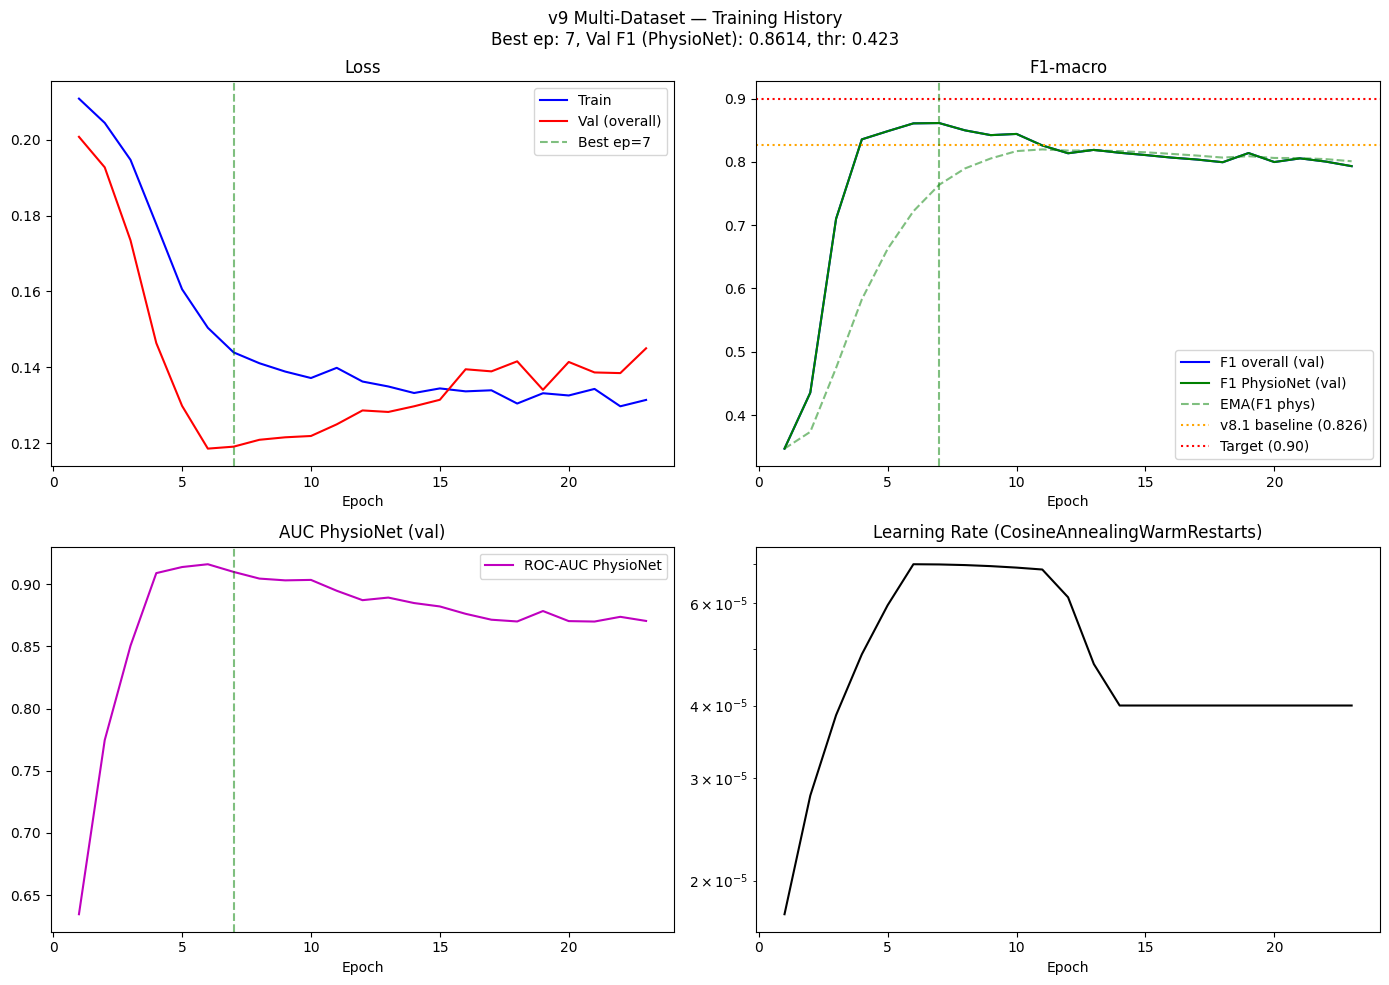

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ep = range(1, len(history['train_loss']) + 1)

axes[0, 0].plot(ep, history['train_loss'], 'b-', label='Train')
axes[0, 0].plot(ep, history['val_loss'], 'r-', label='Val (overall)')
axes[0, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5, label=f'Best ep={best_epoch}')
axes[0, 0].set_title('Loss'); axes[0, 0].legend(); axes[0, 0].set_xlabel('Epoch')

axes[0, 1].plot(ep, history['val_f1_overall'], 'b-', label='F1 overall (val)')
axes[0, 1].plot(ep, history['val_f1_phys'],    'g-', label='F1 PhysioNet (val)')
axes[0, 1].plot(ep, history['val_f1_ema'],     'g--', alpha=0.5, label='EMA(F1 phys)')
axes[0, 1].axhline(0.826, color='orange', ls=':', label='v8.1 baseline (0.826)')
axes[0, 1].axhline(0.90,  color='red',    ls=':', label='Target (0.90)')
axes[0, 1].axvline(best_epoch, color='g', ls='--', alpha=0.5)
axes[0, 1].set_title('F1-macro'); axes[0, 1].legend(); axes[0, 1].set_xlabel('Epoch')

axes[1, 0].plot(ep, history['val_auc_phys'], 'm-', label='ROC-AUC PhysioNet')
axes[1, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5)
axes[1, 0].set_title('AUC PhysioNet (val)'); axes[1, 0].legend(); axes[1, 0].set_xlabel('Epoch')

axes[1, 1].plot(ep, history['lr'], 'k-')
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Learning Rate (CosineAnnealingWarmRestarts)')
axes[1, 1].set_xlabel('Epoch')

plt.suptitle(f'v9 Multi-Dataset — Training History\n'
             f'Best ep: {best_epoch}, Val F1 (PhysioNet): {best_val_f1:.4f}, thr: {best_threshold:.3f}',
             fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_history_v9.png', dpi=140)
plt.show()


## 9. Test Evaluation (PhysioNet held-out, TTA×5)

Финальная оценка — на тех же subjects, что и в v8 (PhysioNet held-out). Сравниваем напрямую с v8.1 baseline (0.826).


In [ ]:
def _eval(y, p, thr, name):
    pred = (p > thr).astype(int)
    f1   = f1_score(y, pred, average='macro', zero_division=0)
    auc  = roc_auc_score(y, p) if len(np.unique(y)) > 1 else float('nan')
    prc  = average_precision_score(y, p) if len(np.unique(y)) > 1 else float('nan')
    bacc = balanced_accuracy_score(y, pred)
    print(f"\n📊 {name} (thr={thr:.3f}):")
    print(f"   F1-macro:     {f1:.4f}")
    print(f"   ROC-AUC:      {auc:.4f}")
    print(f"   PR-AUC:       {prc:.4f}")
    print(f"   Balanced-Acc: {bacc:.4f}")
    print("\n", classification_report(y, pred, target_names=['rested', 'fatigue'], digits=4))
    print("Confusion matrix [rested, fatigue]:")
    print(confusion_matrix(y, pred))
    return {'f1': f1, 'auc': auc, 'pr_auc': prc, 'bacc': bacc, 'threshold': thr}

# ── A) EarlyStopping model (лучшая эпоха по val F1) ──
print(f"Running TTA×{CONFIG['tta_n']} on PhysioNet test ({len(test_ds)} windows) — ES model…")
y_test, p_test_es = predict_with_tta(model, test_ds, DEVICE,
                                      n_tta=CONFIG['tta_n'],
                                      batch_size=CONFIG['batch_size'])

res_es_val = _eval(y_test, p_test_es, best_threshold, "ES model @val-thr")
opt_thr_es, _ = find_best_threshold(y_test, p_test_es)
res_es_opt = _eval(y_test, p_test_es, opt_thr_es, "ES model @test-opt-thr")

# ── B) SWA model (усреднённые веса → плоский минимум) ──
results_swa = {}
if swa_active:
    print(f"\nRunning TTA×{CONFIG['tta_n']} — SWA model…")
    y_test2, p_test_swa = predict_with_tta(swa_model, test_ds, DEVICE,
                                            n_tta=CONFIG['tta_n'],
                                            batch_size=CONFIG['batch_size'])
    # Порог: ищем на val с SWA-моделью
    @torch.no_grad()
    def _val_probs_swa(swa_m, loader, dom_filter):
        swa_m.eval()
        ys, ps, ds = [], [], []
        for imu, physio, hp, dom, y in loader:
            imu = imu.to(DEVICE); physio = physio.to(DEVICE)
            hp = hp.to(DEVICE); dom = dom.to(DEVICE)
            p = torch.sigmoid(swa_m(imu, physio, hp, dom)).cpu().numpy()
            ps.append(p); ys.append(y.numpy()); ds.append(dom.numpy())
        ys = np.concatenate(ys); ps = np.concatenate(ps); ds = np.concatenate(ds)
        m = ds == dom_filter
        return ys[m], ps[m]

    swa_vy, swa_vp = _val_probs_swa(swa_model, val_loader, DOMAIN_MAP['physionet'])
    swa_val_thr, swa_val_f1 = find_best_threshold(swa_vy, swa_vp)
    print(f"SWA val F1 (PhysioNet): {swa_val_f1:.4f}, threshold: {swa_val_thr:.3f}")

    res_swa_val = _eval(y_test2, p_test_swa, swa_val_thr, "SWA model @val-thr")
    opt_thr_swa, _ = find_best_threshold(y_test2, p_test_swa)
    res_swa_opt = _eval(y_test2, p_test_swa, opt_thr_swa, "SWA model @test-opt-thr")
    results_swa = {'val_threshold': res_swa_val, 'optimal_threshold': res_swa_opt,
                   'swa_val_f1': swa_val_f1}

# ── Сравнение ──
print("\n" + "=" * 65)
print(f"📈 СРАВНЕНИЕ:")
print(f"   v8.1 baseline:           F1 = 0.826")
print(f"   v9 ES   @val-thr:        F1 = {res_es_val['f1']:.4f}  ({(res_es_val['f1']-0.826)*100:+.2f}pp)")
print(f"   v9 ES   @opt-thr:        F1 = {res_es_opt['f1']:.4f}  ({(res_es_opt['f1']-0.826)*100:+.2f}pp)")
if swa_active:
    print(f"   v9 SWA  @val-thr:        F1 = {res_swa_val['f1']:.4f}  ({(res_swa_val['f1']-0.826)*100:+.2f}pp)")
    print(f"   v9 SWA  @opt-thr:        F1 = {res_swa_opt['f1']:.4f}  ({(res_swa_opt['f1']-0.826)*100:+.2f}pp)")

# Save results
import json
with open(RESULTS_DIR / 'test_results_v9.json', 'w') as f:
    json.dump({
        'es_model': {'val_threshold': res_es_val, 'optimal_threshold': res_es_opt},
        'swa_model': results_swa,
        'best_epoch': best_epoch, 'val_f1_phys': best_val_f1,
        'config': CONFIG
    }, f, indent=2)
print(f"\n💾 Saved → {RESULTS_DIR / 'test_results_v9.json'}")


Running TTA×5 on PhysioNet test (5760 windows) — ES model…

📊 ES model @val-thr (thr=0.423):
   F1-macro:     0.7166
   ROC-AUC:      0.8780
   PR-AUC:       0.8163
   Balanced-Acc: 0.7566

               precision    recall  f1-score   support

      rested     0.9339    0.5775    0.7137      3522
     fatigue     0.5846    0.9357    0.7196      2238

    accuracy                         0.7167      5760
   macro avg     0.7592    0.7566    0.7166      5760
weighted avg     0.7982    0.7167    0.7160      5760

Confusion matrix [rested, fatigue]:
[[2034 1488]
 [ 144 2094]]

📊 ES model @test-opt-thr (thr=0.489):
   F1-macro:     0.7935
   ROC-AUC:      0.8780
   PR-AUC:       0.8163
   Balanced-Acc: 0.8063

               precision    recall  f1-score   support

      rested     0.8865    0.7672    0.8225      3522
     fatigue     0.6976    0.8454    0.7644      2238

    accuracy                         0.7976      5760
   macro avg     0.7921    0.8063    0.7935      5760
weighted a

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

## 10. Per-domain breakdown (val) — sanity check, что multi-dataset обучение работает на всех доменах


In [ ]:
print("PER-DOMAIN VAL METRICS:")
print("-" * 70)
rows = []
for dom_name, dom_idx in DOMAIN_MAP.items():
    mask = domain_id[val_idx] == dom_idx
    if mask.sum() == 0:
        continue
    _, vm, vy, vp = validate(model, val_loader, criterion, DEVICE,
                              domain_filter=dom_idx, return_raw=True)
    rows.append({
        'Domain': dom_name,
        'N (val)': int(mask.sum()),
        'F1-macro': vm['f1_macro'],
        'ROC-AUC':  vm.get('roc_auc', float('nan')),
        'PR-AUC':   vm.get('pr_auc', float('nan')),
        'Bal-Acc':  vm['balanced_acc'],
    })

per_dom = pd.DataFrame(rows)
print(per_dom.to_string(index=False, float_format='%.4f'))
per_dom.to_csv(RESULTS_DIR / 'per_domain_val_v9.csv', index=False)
print(f"\n💾 Saved → {RESULTS_DIR / 'per_domain_val_v9.csv'}")


PER-DOMAIN VAL METRICS:
----------------------------------------------------------------------
   Domain  N (val)  F1-macro  ROC-AUC  PR-AUC  Bal-Acc
physionet     3454    0.8260   0.8947  0.8638   0.8262

💾 Saved → D:\Github\afc_lab\results_v9_multidataset\per_domain_val_v9.csv


## 11. Summary

### План эксперимента

1. ✅ Объединили 3 датасета: PhysioNet (23K) + WSD (1K) + 4TU+Zenodo (25K) = ~49K окон
2. ✅ Per-domain z-score нормализация (базовые HR/EDA сильно различаются между источниками)
3. ✅ Subject-level split (no leakage), test = только PhysioNet held-out subjects
4. ✅ Архитектура с domain embedding + FiLM modulation + has_physio masking
5. ✅ Domain-weighted loss (PhysioNet ×1.5)
6. ✅ R-Drop consistency regularization
7. ✅ TTA×5 + threshold optimization

### Что нужно проверить после запуска

- **Test F1 (val-thr) > 0.826** → multi-dataset reading действительно помог
- **PhysioNet F1 в per-domain breakdown** должен быть выше остальных (мы целенаправленно его прокачиваем)
- Если F1 4TU/Zenodo тоже растёт — отлично, transfer learning работает
- Если F1 на PhysioNet upal — значит другие домены добавляют шум, надо повысить `physionet_weight` до 2.0–3.0

### Если не достигли 0.9

В `docs/v8_experiments_summary.md` есть Tier 1 идеи:
- Длинное окно (window=300–600)
- Инженерные HRV-фичи
- Pretrain-then-finetune (вместо joint training)
- Per-subject calibration на test
